# 01 — Population : qui sont les répondants ?

Ce notebook ouvre la série d'analyses de l'enquête alimentaire. Avant d'interpréter
*ce que les gens mangent et croient*, il faut savoir **qui** a répondu : c'est l'objet
de cette première étape.

On y décrit le profil socio-démographique de l'échantillon (sexe, âge, géographie,
catégorie socio-professionnelle, niveau d'étude, régimes particuliers) et on en tire
les **limites de représentativité** à garder en tête pour tous les notebooks suivants.

## 1. Préparation des données

On réutilise les fonctions de chargement et de nettoyage de l'application
(`utils/data_loader.py`) afin que notebooks et application reposent exactement sur la
même logique : conversion des fréquences de consommation en scores numériques,
recodage des tranches d'âge et du sexe.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, Markdown

from utils.data_loader import load_data, clean_data

sns.set_theme(style="whitegrid", palette="muted")
AGE_ORDER = ["-18", "18-34", "35-60", "+60"]
ETU_ORDER = ["Brevet", "Bac", "Bac+3", "Bac +5"]

df = clean_data(load_data())
print(f"{df.shape[0]} répondants, {df.shape[1]} colonnes après enrichissement")

1681 répondants, 62 colonnes après enrichissement


Le jeu de données compte **1 681 répondants**. Le nombre de colonnes est supérieur aux
51 variables brutes du questionnaire car `clean_data` ajoute les scores de consommation
numériques (`*_num`) et les scores synthétiques, exploités dans les notebooks suivants.

## 2. Vue d'ensemble

Quelques indicateurs de cadrage avant d'entrer dans le détail.

In [2]:
n = df.shape[0]
overview = pd.DataFrame({
    "Indicateur": ["Répondants", "Variables", "% Femmes", "% Zone rurale", "% Régime spécifique"],
    "Valeur": [
        n,
        df.shape[1],
        f"{df['Sexe'].eq('Femme').mean() * 100:.1f} %",
        f"{df['Rura'].eq('Rural').mean() * 100:.1f} %",
        f"{df['Regime_B'].eq('Oui').mean() * 100:.1f} %",
    ],
})
display(Markdown(overview.to_markdown(index=False)))

| Indicateur          | Valeur   |
|:--------------------|:---------|
| Répondants          | 1681     |
| Variables           | 62       |
| % Femmes            | 73.1 %   |
| % Zone rurale       | 39.2 %   |
| % Régime spécifique | 16.8 %   |

L'échantillon est **majoritairement féminin** (≈ 73 %) et **plutôt urbain** (≈ 61 %).
Un répondant sur six déclare suivre un régime alimentaire particulier. Ces premiers
chiffres annoncent déjà un échantillon éloigné de la population générale.

## 3. Profil démographique : sexe et âge

On visualise la répartition par sexe et par tranche d'âge (ordonnée du plus jeune au
plus âgé).

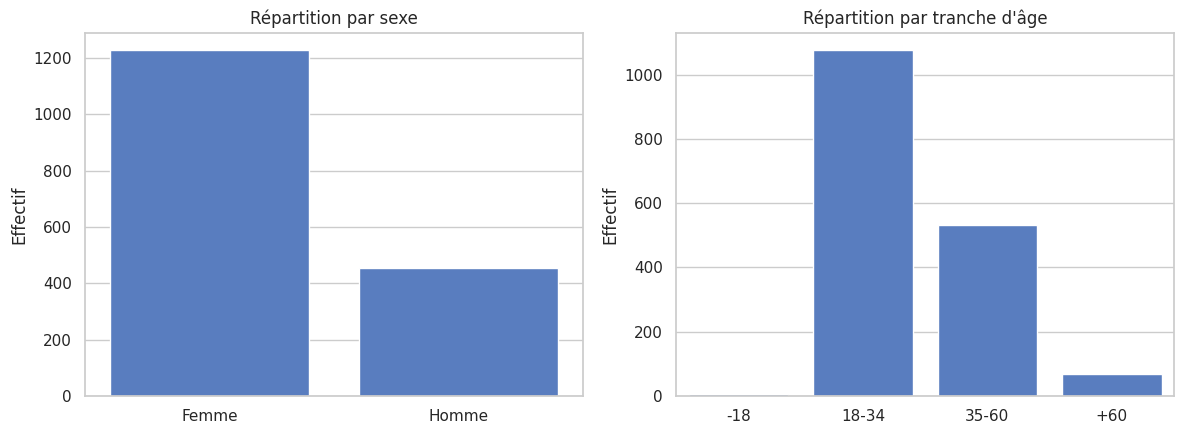

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x="Sexe", ax=axes[0], order=df["Sexe"].value_counts().index)
axes[0].set_title("Répartition par sexe"); axes[0].set_xlabel(""); axes[0].set_ylabel("Effectif")
sns.countplot(data=df, x="Age", ax=axes[1], order=AGE_ORDER)
axes[1].set_title("Répartition par tranche d'âge"); axes[1].set_xlabel(""); axes[1].set_ylabel("Effectif")
fig.tight_layout()

Le déséquilibre est net : près de **trois répondants sur quatre sont des femmes**, et
la tranche **18-34 ans concentre 64 % de l'échantillon** (95 % des répondants ont entre
18 et 60 ans). Les moins de 18 ans et les plus de 60 ans sont quasi absents. On a donc
affaire à une population **jeune et adulte active**, pas à un échantillon tous âges.

## 4. Répartition géographique

Deux dimensions géographiques sont disponibles : la zone macro (Nord / Sud) et le type
de territoire (rural / citadin).

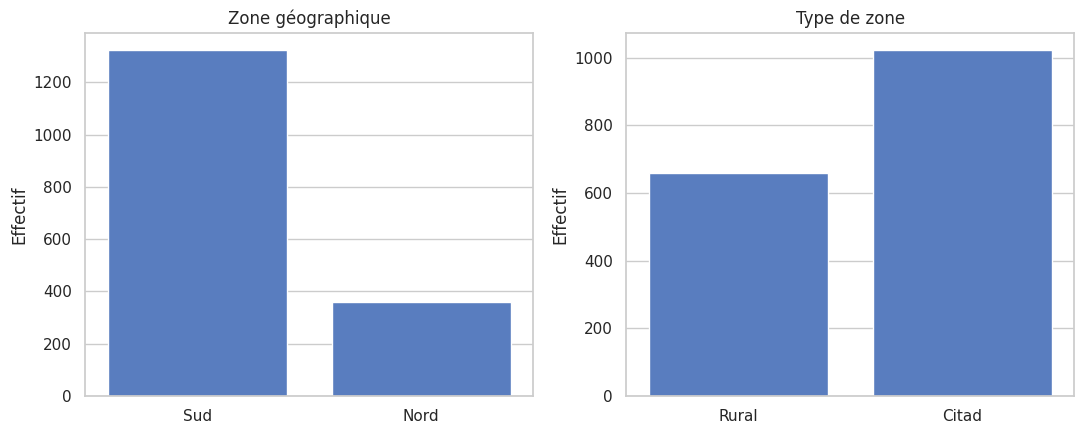

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(data=df, x="Card", ax=axes[0])
axes[0].set_title("Zone géographique"); axes[0].set_xlabel(""); axes[0].set_ylabel("Effectif")
sns.countplot(data=df, x="Rura", ax=axes[1])
axes[1].set_title("Type de zone"); axes[1].set_xlabel(""); axes[1].set_ylabel("Effectif")
fig.tight_layout()

La collecte est **fortement concentrée dans le Sud** (≈ 79 % des répondants) et penche
vers les zones **citadines** (≈ 61 %). Toute lecture d'un effet « géographique » dans les
notebooks suivants devra tenir compte de ce déséquilibre Nord/Sud marqué.

## 5. Catégorie socio-professionnelle et niveau d'étude

On décrit la structure sociale de l'échantillon : profession et diplôme.

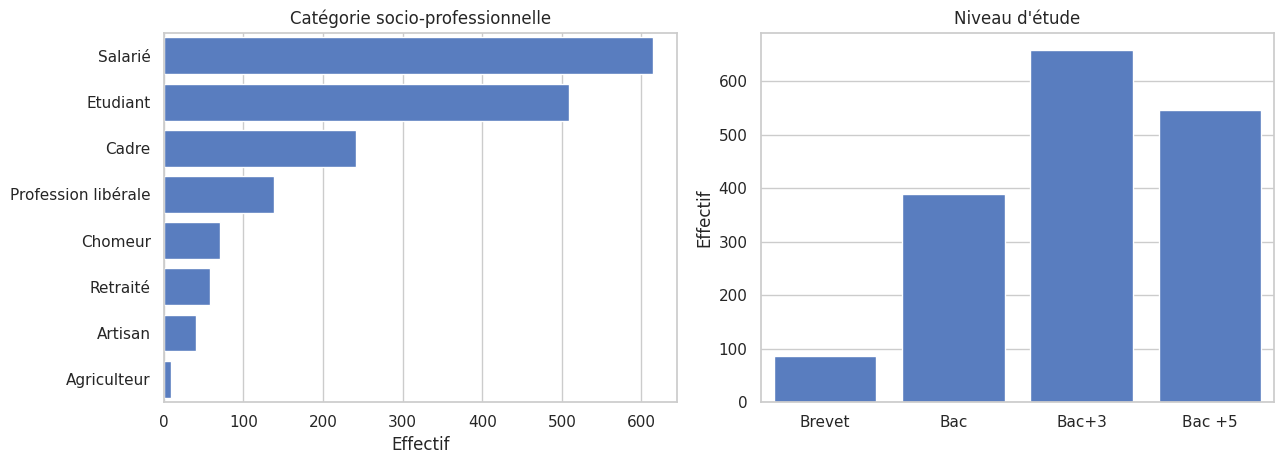

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.countplot(data=df, y="pro", ax=axes[0], order=df["pro"].value_counts().index)
axes[0].set_title("Catégorie socio-professionnelle"); axes[0].set_xlabel("Effectif"); axes[0].set_ylabel("")
sns.countplot(data=df, x="Etud", ax=axes[1], order=[e for e in ETU_ORDER if e in df["Etud"].unique()])
axes[1].set_title("Niveau d'étude"); axes[1].set_xlabel(""); axes[1].set_ylabel("Effectif")
fig.tight_layout()

Les **salariés** et les **étudiants** forment le gros des répondants, cohérent avec la
domination des 18-34 ans. Surtout, l'échantillon est **très diplômé** : près de **72 %
ont au moins un Bac+3**. C'est un biais de niveau d'étude majeur, qui pèse directement sur
les connaissances nutritionnelles et les pratiques observées plus loin.

## 6. Croisement âge × sexe

On croise les deux variables démographiques principales pour visualiser la structure
fine de l'échantillon.

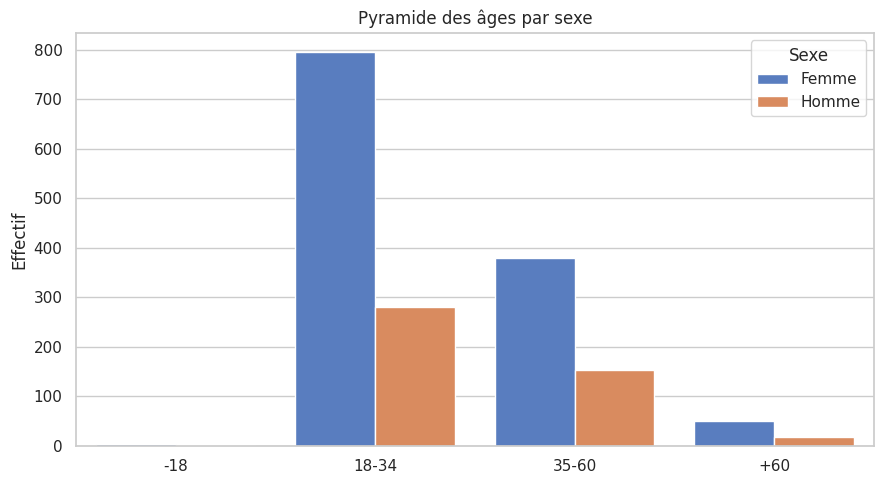

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x="Age", hue="Sexe", order=AGE_ORDER, ax=ax)
ax.set_title("Pyramide des âges par sexe"); ax.set_xlabel(""); ax.set_ylabel("Effectif")
fig.tight_layout()

Le tableau de contingence chiffre cette structure.

In [7]:
ct = pd.crosstab(df["Age"], df["Sexe"]).reindex(AGE_ORDER)
display(Markdown(ct.to_markdown()))

| Age   |   Femme |   Homme |
|:------|--------:|--------:|
| -18   |       3 |       2 |
| 18-34 |     795 |     281 |
| 35-60 |     380 |     153 |
| +60   |      50 |      17 |

La surreprésentation féminine se vérifie **dans toutes les tranches d'âge** : ce n'est pas
l'effet d'une classe d'âge particulière mais un biais transversal de l'échantillon. Les
femmes de 18-34 ans constituent à elles seules près de la moitié des répondants.

## 7. Régimes alimentaires particuliers

Au-delà du socio-démographique, on relève les régimes spécifiques déclarés, qui peuvent
modifier la lecture des consommations.

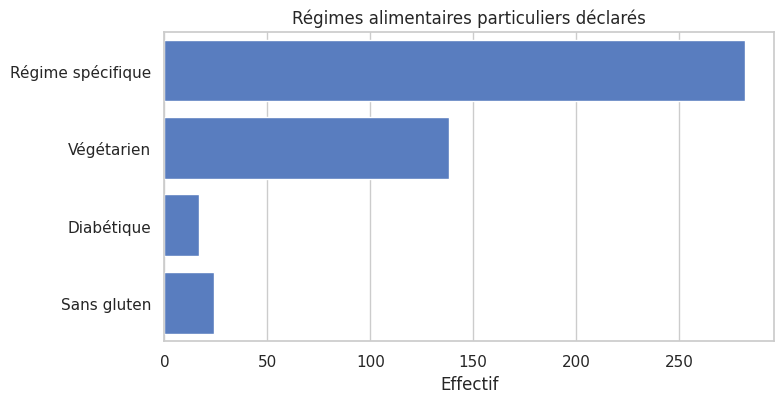

In [8]:
regimes = {
    "Régime spécifique": int(df["Regime_B"].eq("Oui").sum()),
    "Végétarien": int(df["végétarien"].sum()),
    "Diabétique": int(df["diabétique"].sum()),
    "Sans gluten": int(df["gluten"].sum()),
}
reg_df = pd.DataFrame({"Régime": list(regimes), "Effectif": list(regimes.values())})
reg_df["% échantillon"] = (reg_df["Effectif"] / n * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=reg_df, y="Régime", x="Effectif", ax=ax)
ax.set_title("Régimes alimentaires particuliers déclarés"); ax.set_xlabel("Effectif"); ax.set_ylabel("")
fig.tight_layout()

Le détail chiffré :

In [9]:
display(Markdown(reg_df.to_markdown(index=False)))

| Régime            |   Effectif |   % échantillon |
|:------------------|-----------:|----------------:|
| Régime spécifique |        282 |            16.8 |
| Végétarien        |        138 |             8.2 |
| Diabétique        |         17 |             1   |
| Sans gluten       |         24 |             1.4 |

Le **végétarisme** est le régime particulier le plus fréquent (≈ 8 %), loin devant les
contraintes médicales (diabète, sans gluten : ~1 % chacune). Cette part non négligeable
de végétariens est à garder en tête lors de l'analyse des consommations de viande.

## 8. Synthèse & limites de représentativité

**Profil type du répondant.** Une femme (≈ 73 %), jeune adulte de 18-34 ans (64 %),
citadine (≈ 61 %), résidant dans le Sud (≈ 79 %), diplômée du supérieur (≈ 72 % de
Bac+3 ou plus), salariée ou étudiante.

**Limites à retenir pour toute la suite.** L'échantillon **n'est pas représentatif** de
la population générale française. Sont nettement surreprésentés : les femmes, les 18-34
ans, les diplômés du supérieur et le Sud. En conséquence :

- les résultats décrivent surtout les habitudes d'un public **jeune, urbain et éduqué** ;
- les comparaisons par sous-groupe à faibles effectifs (−18 ans, +60 ans, agriculteurs,
  diabétiques…) doivent être lues avec **prudence** ;
- les tests statistiques des notebooks suivants restent valides *au sein de l'échantillon*,
  mais leur **généralisation** à la population entière n'est pas garantie.

Ce cadrage posé, on peut passer à l'analyse du cœur du sujet : les **habitudes de
consommation et les scores de santé** (notebook 02).